In [341]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import locale
import numpy as np
from math import sqrt
import statistics

In [310]:
from math import nan


data = pd.read_csv("./datasets/titanic.csv")

# declaring x and y
x = data.drop(columns=["PassengerId", "Survived", "Name", "Ticket", "Fare", "Cabin", "Embarked"])
y = data["Survived"]

# numerizing data
x["Sex"] = x["Sex"].map({'male': 1, 'female': 0})
x["Age"] = x["Age"].replace({nan: round(x["Age"].mean())})

# variable for future use
dataset_count = len(y)
feature_count = len(x.iloc[0])

# making tensor x and y
x_tensor = torch.tensor(x.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32)
y_tensor = y_tensor.unsqueeze(dim=1)

x_max = x_tensor.max(dim=0, keepdim=True).values

x_tensor = x_tensor / x_max

# making x scaled and clean
x_max_df = x_max.squeeze().tolist()
x_scaled = x.div(x_max_df, 1)

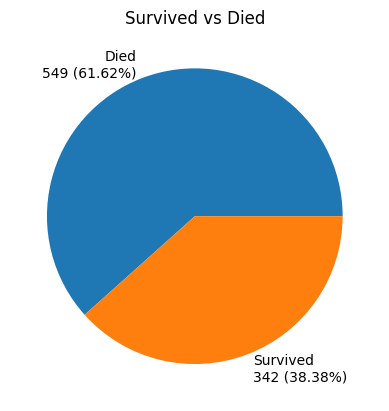

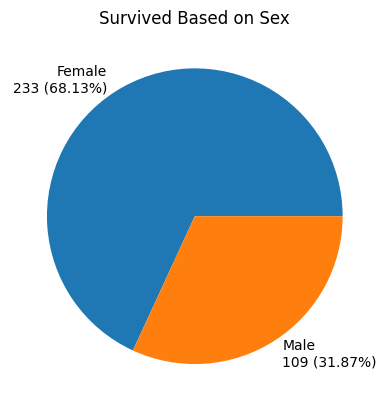

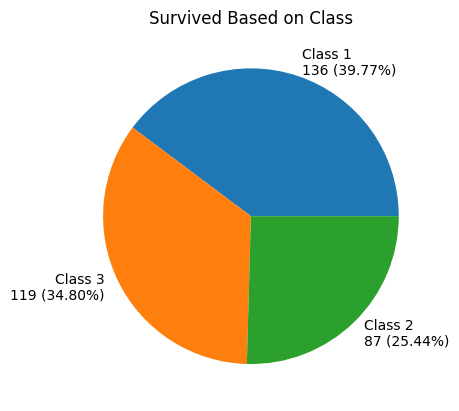

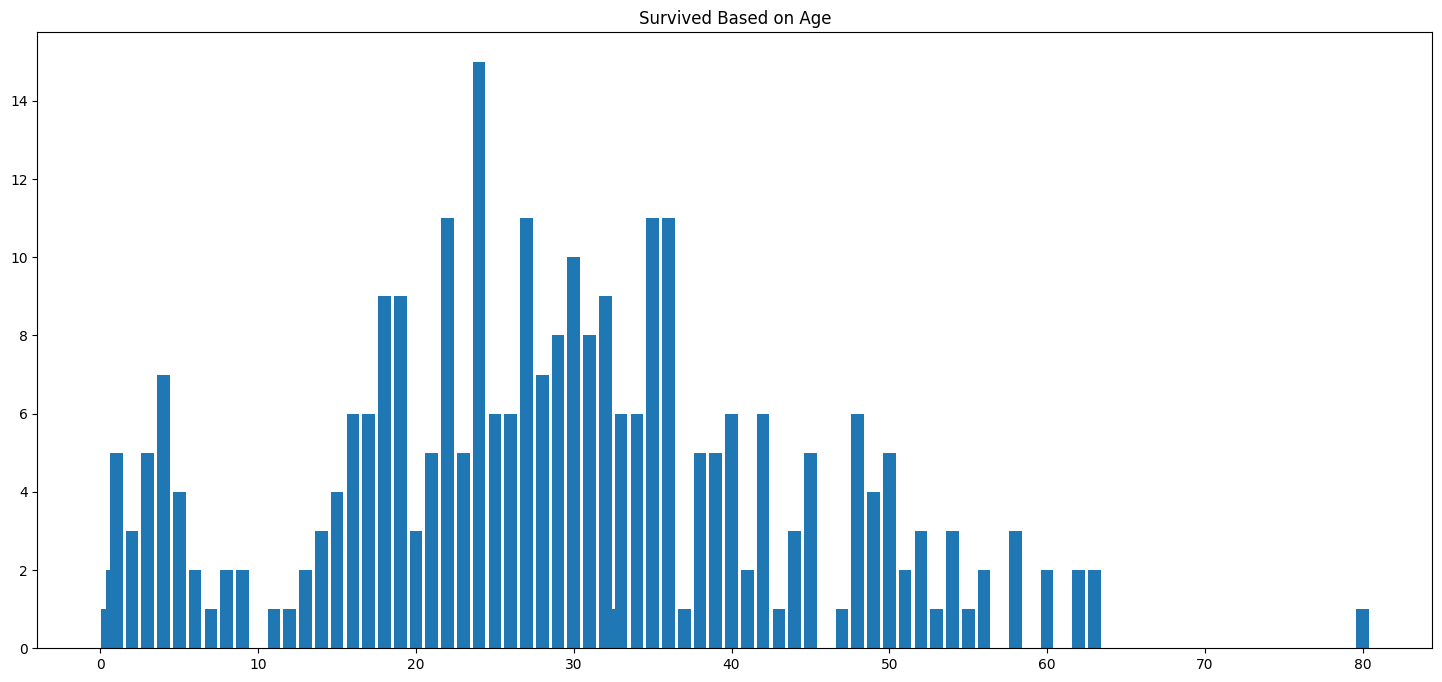

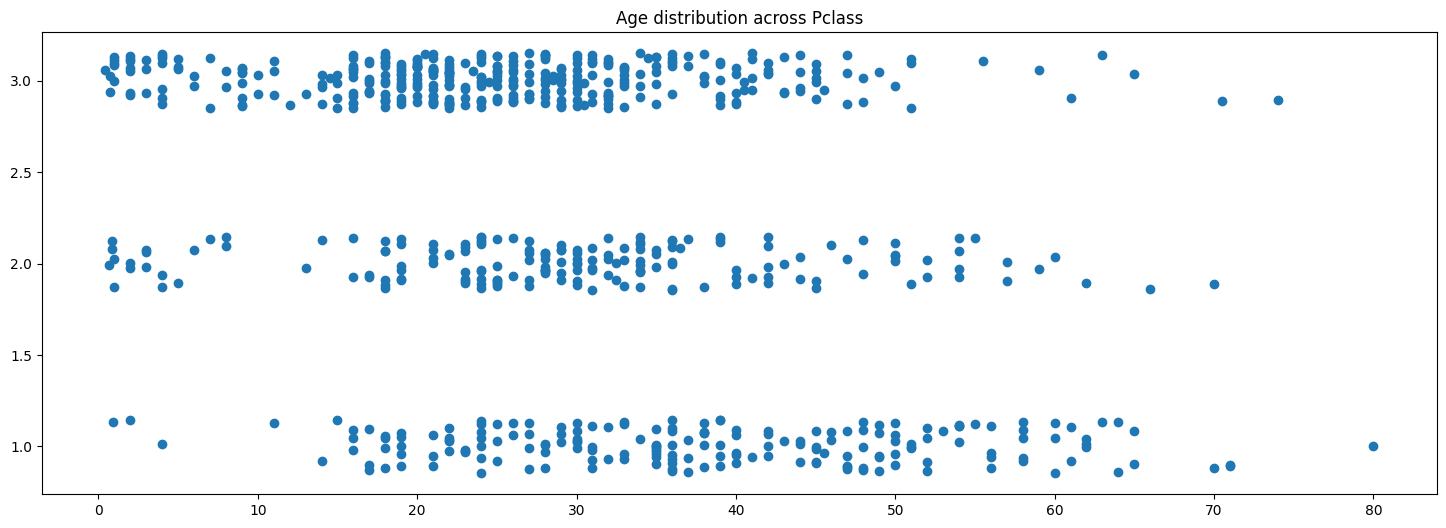

In [264]:
# data trend
def percentage(data, whole_list):
    return f"({(data / sum(whole_list) * 100):.2f}%)"

survived_value_counts = list(data["Survived"].value_counts())
plt.pie(survived_value_counts, labels=[f"Died\n{survived_value_counts[0]} {percentage(survived_value_counts[0], survived_value_counts)}", f"Survived\n{survived_value_counts[1]} {percentage(survived_value_counts[1], survived_value_counts)}"])
plt.title("Survived vs Died")
plt.show()

survived_sex_value_counts = list(((data[data["Survived"] == 1])["Sex"]).value_counts())
plt.pie(survived_sex_value_counts, labels=[f"Female\n{survived_sex_value_counts[0]} {percentage(survived_sex_value_counts[0], survived_sex_value_counts)}", f"Male\n{survived_sex_value_counts[1]} {percentage(survived_sex_value_counts[1], survived_sex_value_counts)}"])
plt.title("Survived Based on Sex")
plt.show()

survived_pclass_value_counts = list(((data[data["Survived"] == 1])["Pclass"]).value_counts())
plt.pie(survived_pclass_value_counts, labels=[f"Class 1\n{survived_pclass_value_counts[0]} {percentage(survived_pclass_value_counts[0], survived_pclass_value_counts)}", f"Class 3\n{survived_pclass_value_counts[1]} {percentage(survived_pclass_value_counts[1], survived_pclass_value_counts)}", f"Class 2\n{survived_pclass_value_counts[2]} {percentage(survived_pclass_value_counts[2], survived_pclass_value_counts)}"])
plt.title("Survived Based on Class")
plt.show()

survived_age_value_counts = ((data[data["Survived"] == 1])["Age"]).value_counts()
plt.figure(figsize=(18, 8))
plt.bar(survived_age_value_counts.index.tolist(), survived_age_value_counts.values.tolist())
plt.title("Survived Based on Age")
plt.show()

plt.figure(figsize=(18, 6))
pclass_list = data["Pclass"].tolist()
age_list = data["Age"].tolist()
noise = np.random.uniform(-0.15, 0.15, size=len(age_list))
plt.scatter(age_list, pclass_list + noise)
plt.title("Age distribution across Pclass")
plt.show()


## Model 1: Neural Network

In [88]:
class Classification(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(feature_count, feature_count ** 2)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(feature_count ** 2, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.sigmoid(x)
        return x
    
model = Classification()
loss = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-2)

In [265]:
for epoch in range(5000):
    output = model(x_tensor)
    
    l = loss(output, y_tensor)
    
    l.backward()
    
    optimizer.step()
    optimizer.zero_grad()
    
    print(f"epoch {epoch} = loss: {l}")

epoch 0 = loss: 0.3785582482814789
epoch 1 = loss: 0.3789459764957428
epoch 2 = loss: 0.37913960218429565
epoch 3 = loss: 0.37944522500038147
epoch 4 = loss: 0.3793860673904419
epoch 5 = loss: 0.3795328736305237
epoch 6 = loss: 0.37932246923446655
epoch 7 = loss: 0.379329115152359
epoch 8 = loss: 0.3791380226612091
epoch 9 = loss: 0.3791522681713104
epoch 10 = loss: 0.3788732588291168
epoch 11 = loss: 0.37871459126472473
epoch 12 = loss: 0.37846872210502625
epoch 13 = loss: 0.37832486629486084
epoch 14 = loss: 0.37814027070999146
epoch 15 = loss: 0.37798893451690674
epoch 16 = loss: 0.3778841197490692
epoch 17 = loss: 0.37783852219581604
epoch 18 = loss: 0.37777969241142273
epoch 19 = loss: 0.3777484595775604
epoch 20 = loss: 0.37777963280677795
epoch 21 = loss: 0.3778477907180786
epoch 22 = loss: 0.3779349625110626
epoch 23 = loss: 0.3781845271587372
epoch 24 = loss: 0.37855595350265503
epoch 25 = loss: 0.3791690468788147
epoch 26 = loss: 0.3796868324279785
epoch 27 = loss: 0.38069295

In [266]:
pclass = 1
sex = 1
age = 18
sibSp = 0
parch = 0

test_data = torch.tensor([pclass, sex, age, sibSp, parch], dtype=torch.float32) / x_max

alive_prob = int(model(test_data)[0, 0].tolist() * 100)

print(f"survive probability: {alive_prob}%")

survive probability: 15%


## Model 2: K-Nearest Neighbor (KNN)

In [380]:
# X is a matrix
# Y is a matrix
# x_new is a vector
# k is how many data took part in the decision

def KNN(x, y, x_new, k):
    distances = []
    
    for sample_index in range(len(x)):
        distance = 0
        
        for feature_index in range(len(x.iloc[sample_index])):
            distance += (x.iloc[sample_index, feature_index] - x_new.iloc[feature_index]) ** 2
            
        distance = sqrt(distance)
        distances.append([sample_index, distance])
    
    distances.sort(key=lambda x: x[1])
    
    distances = distances[0:k]
    
    nearest_indexes = [row[0] for row in distances]
    
    votes = []
    
    for nearest_index in nearest_indexes:
        votes.append(int(y.iloc[nearest_index]))
    
    winner = statistics.mode(votes)
        
    voter_data = (x.iloc[nearest_indexes]).mul(x_max_df, 1)
    
    voter_data["Survived"] = votes
    
    voter_data["Sex"] = voter_data["Sex"].replace({0: "female", 1: "male"})
    voter_data["Survived"] = voter_data["Survived"].replace({0: "no", 1: "yes"})
    
    return {
        "Alive": True if winner == 1 else False,
        "Neighbors": voter_data
    }

In [ ]:
# pclass = 1
# sex = 1
# age = 10
# sibSp = 0
# parch = 0


# test_data = pd.DataFrame({"Pclass": [pclass], "Sex": [sex], "Age": [age], "SibSp": [sibSp], "Parch": [parch]})
# print(x_max_df)
# print(test_data.div(x_max_df))
# print(x_scaled.iloc[777])
# print(KNN(x_scaled, y, test_data, 5))

[3.0, 1.0, 80.0, 8.0, 6.0]
     Pclass  Sex    Age  SibSp  Parch
0  0.333333  1.0  0.125    0.0    0.0
Pclass    1.0000
Sex       0.0000
Age       0.0625
SibSp     0.0000
Parch     0.0000
Name: 777, dtype: float64


IndexError: single positional indexer is out-of-bounds